# Import the libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [6]:
df=pd.read_csv("winequality-red-1.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


### Create a model to predict the wine quality

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


#### Observation:
- 1599 records,12 columns
- No missing values 
- No categorical values
- Except target var,all the input var are real numerical data columns 
- target var is discrete numerical column

#### Check Duplicates

In [8]:
df.duplicated().sum()

np.int64(240)

#### Drop Duplicate

In [9]:
df.drop_duplicates(inplace=True)

## Verify the outliers

<Axes: title={'center': 'Boxplot for Fixed Acidity'}, xlabel='fixed acidity'>

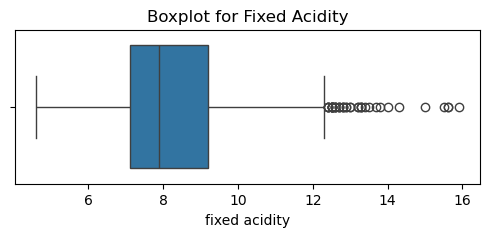

In [10]:
# use boxplot
plt.figure(figsize=(6,2))
plt.title("Boxplot for Fixed Acidity")
sns.boxplot(df["fixed acidity"],orient="h")

<Axes: title={'center': 'Boxplot for volatile acidity'}, xlabel='volatile acidity'>

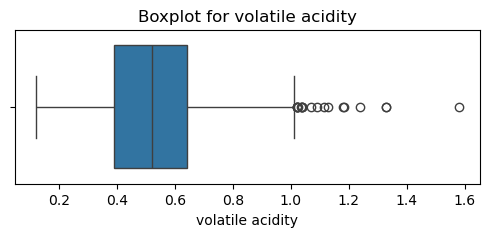

In [26]:
plt.figure(figsize=(6,2))
plt.title("Boxplot for volatile acidity")
sns.boxplot(df["volatile acidity"],orient="h")

<Axes: title={'center': 'Boxplot for citric acid'}, xlabel='citric acid'>

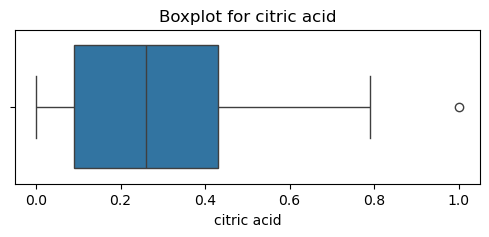

In [12]:
plt.figure(figsize=(6,2))
plt.title("Boxplot for citric acid")
sns.boxplot(df["citric acid"],orient="h")

<Axes: title={'center': 'Boxplot for residual sugar'}, xlabel='residual sugar'>

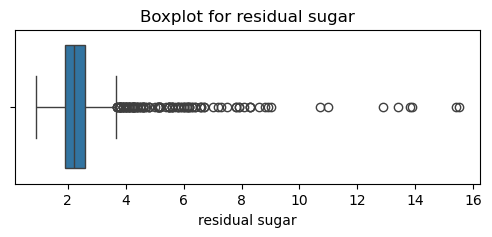

In [27]:
plt.figure(figsize=(6,2))
plt.title("Boxplot for residual sugar")
sns.boxplot(df["residual sugar"],orient="h")

<Axes: title={'center': 'Boxplot for chlorides'}, xlabel='chlorides'>

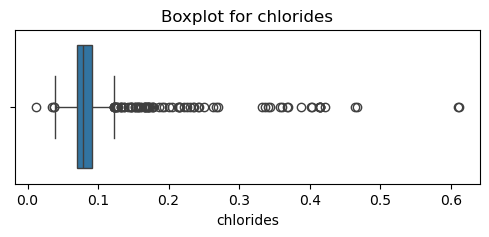

In [20]:

plt.figure(figsize=(6,2))
plt.title("Boxplot for chlorides")
sns.boxplot(df["chlorides"],orient="h")

<Axes: title={'center': 'Boxplot for free sulfur dioxide'}, xlabel='free sulfur dioxide'>

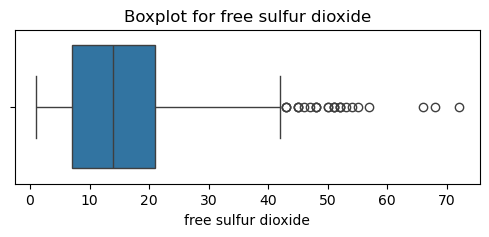

In [28]:
plt.figure(figsize=(6,2))
plt.title("Boxplot for free sulfur dioxide")
sns.boxplot(df["free sulfur dioxide"],orient="h")

<Axes: title={'center': 'Boxplot for density '}, xlabel='density'>

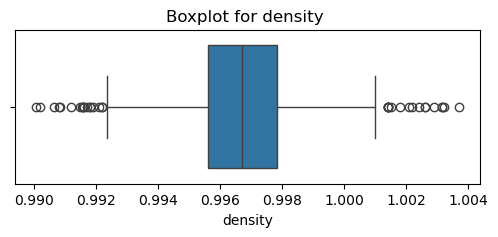

In [22]:
plt.figure(figsize=(6,2))
plt.title("Boxplot for density ")
sns.boxplot(df["density"],orient="h")

<Axes: title={'center': 'Boxplot for pH '}, xlabel='pH'>

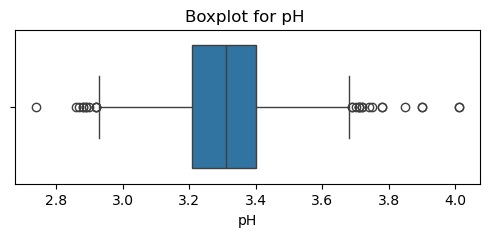

In [29]:
plt.figure(figsize=(6,2))
plt.title("Boxplot for pH ")
sns.boxplot(df["pH"],orient="h")

<Axes: title={'center': 'Boxplot for sulphates '}, xlabel='sulphates'>

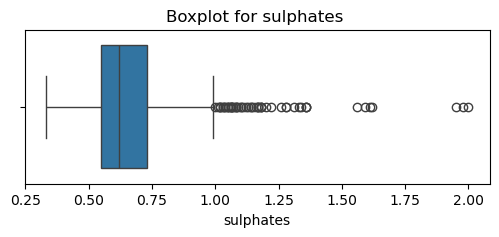

In [24]:
plt.figure(figsize=(6,2))
plt.title("Boxplot for sulphates ")
sns.boxplot(df["sulphates"],orient="h")

<Axes: title={'center': 'Boxplot for alcohol '}, xlabel='alcohol'>

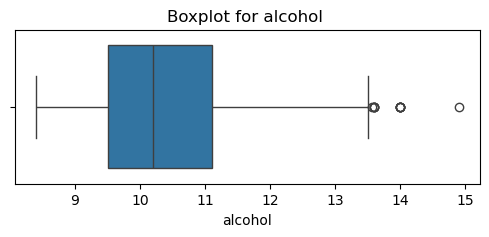

In [30]:
plt.figure(figsize=(6,2))
plt.title("Boxplot for alcohol ")
sns.boxplot(df["alcohol"],orient="h")

<Axes: title={'center': 'Boxplot for quality'}, xlabel='quality'>

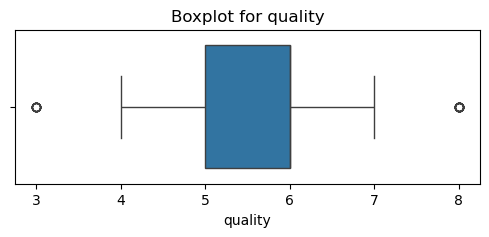

In [25]:
plt.figure(figsize=(6,2))
plt.title("Boxplot for quality")
sns.boxplot(df["quality"],orient="h")

### Observation:
- 1.Except citric acid and alcohol columns,rest of input columns are having outliers.
- 2.Citric acid is having a single outlier and alcohol is having very few outlies.

#### problem statement:
- create a predictive model to get the quality of wine

#### observation:
- quality is the target varibale
- As the target bar is available ,it is a supervised ml model.
- The Data type of quality column is discrete numerical,hence ,it is a classification model


In [31]:
df["quality"].dtype

dtype('int64')

In [32]:
df["quality"].value_counts()

quality
5    577
6    535
7    167
4     53
8     17
3     10
Name: count, dtype: int64

### Lets select the target variable

In [33]:
y=df["quality"]

In [34]:
y.shape

(1359,)

### Let us select the input variables (X) 

In [35]:
X=df.drop(columns="quality")
X.shape

(1359, 11)

In [36]:
X.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4


## 2.Splitting the data into training and test(Train dat and Test data)  lets import tarin split  from sklearn


In [37]:
# pip install sklearn
from sklearn.model_selection import train_test_split

In [38]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [39]:
### lets verify the shape
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(1087, 11)
(272, 11)
(1087,)
(272,)


#### observation:
1. performed train_test_split on input and target var.
2. for traning Input/output-1087 records
3. for traning Input/output -272 records

In [40]:
X.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4


# Numerical data preprocessing


#### Lets compare the data distribution of fixed acidity  and volatile  acidity before scaling

<Axes: xlabel='fixed acidity', ylabel='Density'>

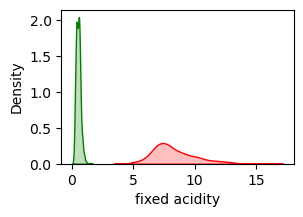

In [41]:
plt.figure(figsize=(3,2))
sns.kdeplot(X_train["fixed acidity"],color="red",fill=True)
sns.kdeplot(X_train["volatile acidity"],color="green",fill=True)

### Observation 
1. To bring the data into same scale,we perform feature Scaling.
2. In the above comparison plot the distribution of both the columns lies in a diffrent scale.

#### Numerical data preprocessing 
1. feature scaling(scaling into one ceratin range)
   - Minmax Scaler
   - Standard Scaler
   - Robust Scaling

2. Feature Transformation(Reshaping)

In [42]:
# MinMax Scaler
from sklearn.preprocessing import MinMaxScaler

In [43]:
norm = MinMaxScaler()

In [44]:
X_trained_trans=norm.fit_transform(X_train)
X_test_trans=norm.fit(X_test)

In [45]:
X_trained_trans

array([[0.16964286, 0.38028169, 0.08      , ..., 0.5511811 , 0.1497006 ,
        0.27692308],
       [0.25      , 0.16901408, 0.18      , ..., 0.47244094, 0.1497006 ,
        0.15384615],
       [0.39285714, 0.14788732, 0.32      , ..., 0.44094488, 0.28143713,
        0.43076923],
       ...,
       [0.28571429, 0.12676056, 0.42      , ..., 0.48031496, 0.16167665,
        0.46153846],
       [0.23214286, 0.29577465, 0.3       , ..., 0.56692913, 0.15568862,
        0.27692308],
       [0.16964286, 0.29577465, 0.02      , ..., 0.50393701, 0.19760479,
        0.64615385]], shape=(1087, 11))

In [46]:
X_train_trans_df=pd.DataFrame(X_trained_trans,columns=X_train.columns)
X_train_trans_df


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,0.169643,0.380282,0.08,0.116438,0.157191,0.183099,0.132075,0.483113,0.551181,0.149701,0.276923
1,0.250000,0.169014,0.18,0.047945,0.112040,0.323944,0.327044,0.472100,0.472441,0.149701,0.153846
2,0.392857,0.147887,0.32,0.082192,0.086957,0.042254,0.056604,0.417768,0.440945,0.281437,0.430769
3,0.303571,0.394366,0.09,0.130137,0.120401,0.239437,0.270440,0.685022,0.543307,0.233533,0.415385
4,0.366071,0.316901,0.30,0.130137,0.127090,0.225352,0.251572,0.552863,0.409449,0.107784,0.138462
...,...,...,...,...,...,...,...,...,...,...,...
1082,0.392857,0.084507,0.46,0.554795,0.170569,0.028169,0.018868,0.656388,0.346457,0.161677,0.384615
1083,0.169643,0.397887,0.20,0.472603,0.102007,0.394366,0.459119,0.560206,0.433071,0.125749,0.123077
1084,0.285714,0.126761,0.42,0.075342,0.123746,0.098592,0.081761,0.395742,0.480315,0.161677,0.461538
1085,0.232143,0.295775,0.30,0.102740,0.103679,0.197183,0.308176,0.494126,0.566929,0.155689,0.276923


<Axes: xlabel='fixed acidity', ylabel='Density'>

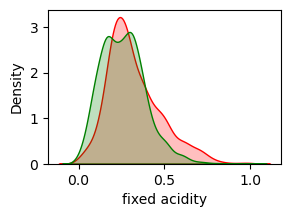

In [47]:
plt.figure(figsize=(3,2))
sns.kdeplot(X_train_trans_df["fixed acidity"],color="red",fill=True)
sns.kdeplot(X_train_trans_df["volatile acidity"],color="green",fill=True)

# 2.StandardScaler/Standardixation

# Z-score=(x-mu/stdv)

In [48]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()

In [49]:
X_train_trans2=sc.fit_transform(X_train)
X_test_trans2=sc.fit(X_test)

In [50]:
X_train_trans2_df=pd.DataFrame(X_train_trans2,columns=X_train.columns)
X_train_trans2_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.973113,0.927389,-0.967666,0.058068,0.401570,-0.182396,-0.598539,-0.029270,0.826209,-0.452848,-0.216484
1,-0.458465,-0.697703,-0.457355,-0.663298,-0.175678,0.764878,0.360359,-0.109090,0.182833,-0.452848,-0.956771
2,0.456466,-0.860212,0.257080,-0.302615,-0.496372,-1.129670,-0.969726,-0.502870,-0.074518,0.800411,0.708874
3,-0.115366,1.035728,-0.916634,0.202341,-0.068780,0.196514,0.081969,1.434102,0.761871,0.344680,0.616338
4,0.284916,0.439861,0.155018,0.202341,0.016738,0.101786,-0.010828,0.476259,-0.331869,-0.851612,-1.049307


In [51]:
X_train_trans2_df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,1.087000e+03,1.087000e+03,1.087000e+03,1.087000e+03,1.087000e+03,1.087000e+03,1.087000e+03,1.087000e+03,1.087000e+03,1.087000e+03,1.087000e+03
mean,-2.908846e-16,-2.941529e-17,6.209895e-17,-2.696402e-16,3.938381e-16,3.268366e-18,-1.225637e-16,4.413928e-14,1.026267e-15,-1.380885e-16,-1.330225e-15
std,1.000460e+00,1.000460e+00,1.000460e+00,1.000460e+00,1.000460e+00,1.000460e+00,1.000460e+00,1.000460e+00,1.000460e+00,1.000460e+00,1.000460e+00
min,-2.059593e+00,-1.997777e+00,-1.375914e+00,-1.168253e+00,-1.608109e+00,-1.413852e+00,-1.248115e+00,-3.530720e+00,-3.677426e+00,-1.877006e+00,-1.882129e+00
25%,-6.871974e-01,-7.518729e-01,-9.166344e-01,-4.468881e-01,-3.894740e-01,-8.454876e-01,-7.841325e-01,-5.880119e-01,-6.535568e-01,-6.237471e-01,-8.642352e-01
50%,-2.297322e-01,-4.766637e-02,-4.910625e-02,-2.304785e-01,-1.756783e-01,-1.823960e-01,-2.892174e-01,-2.663124e-03,-1.018038e-02,-2.249829e-01,-2.164845e-01
75%,5.136489e-01,6.023704e-01,8.184219e-01,5.806759e-02,5.949696e-02,4.806957e-01,4.840874e-01,5.933283e-01,5.688584e-01,4.016466e-01,7.088738e-01
max,4.344921e+00,5.694325e+00,3.727193e+00,9.363680e+00,1.117687e+01,5.311792e+00,3.670103e+00,3.716962e+00,4.493454e+00,7.636369e+00,4.132699e+00


<Axes: xlabel='fixed acidity', ylabel='Density'>

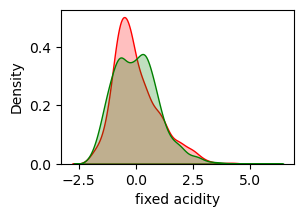

In [52]:
plt.figure(figsize=(3,2))
sns.kdeplot(X_train_trans2_df["fixed acidity"],color="red",fill=True)
sns.kdeplot(X_train_trans2_df["volatile acidity"],color="green",fill=True)

<Axes: ylabel='fixed acidity'>

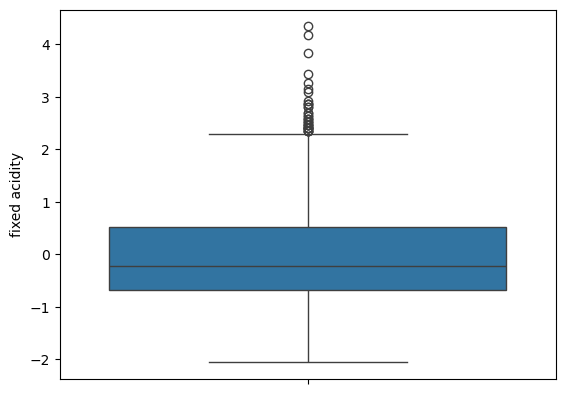

In [53]:
sns.boxplot(X_train_trans2_df["fixed acidity"])

# 3.RobustScaler:


In [54]:
#x_scale=x-median/IQR

In [55]:
from sklearn.preprocessing import RobustScaler
rc=RobustScaler()

### transform the tarin and test input
X_train_trans3=rc.fit_transform(X_train)
X_test_trans3=rc.fit(X_test)

In [56]:
X_train3_df=pd.DataFrame(X_train_trans3,columns=X_train.columns)

In [57]:
X_train3_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.619048,0.72,-0.529412,0.571429,1.285714,0.000000,-0.243902,-0.022523,0.684211,-0.222222,0.000000
1,-0.190476,-0.48,-0.235294,-0.857143,0.000000,0.714286,0.512195,-0.090090,0.157895,-0.222222,-0.470588
2,0.571429,-0.60,0.176471,-0.142857,-0.714286,-0.714286,-0.536585,-0.423423,-0.052632,1.000000,0.588235
3,0.095238,0.80,-0.500000,0.857143,0.238095,0.285714,0.292683,1.216216,0.631579,0.555556,0.529412
4,0.428571,0.36,0.117647,0.857143,0.428571,0.214286,0.219512,0.405405,-0.263158,-0.611111,-0.529412


<Axes: xlabel='fixed acidity', ylabel='Density'>

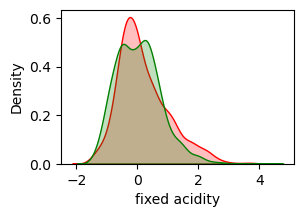

In [58]:
plt.figure(figsize=(3,2))
sns.kdeplot(X_train3_df["fixed acidity"] , color = "red" , fill = True)
sns.kdeplot(X_train3_df["volatile acidity"], color = "green" , fill = True)

<Axes: ylabel='fixed acidity'>

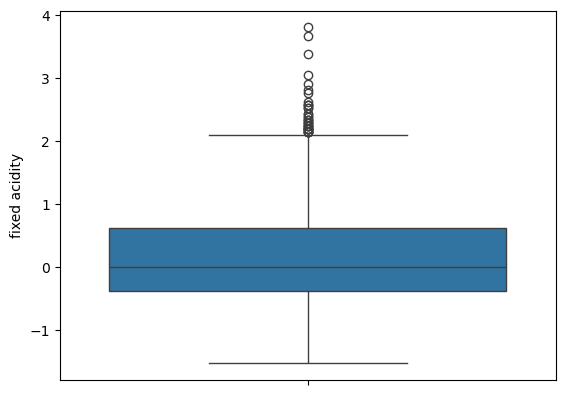

In [59]:
sns.boxplot(X_train3_df["fixed acidity"])

# DATA TRANSFORMATION / FEATURE TRANSFORMATION

- to convert **non normal distribution** into a **normal distribution**.

- various transformations are:

    - **log transformation** : if the data is **slightly right skewed**.
    - **box-cox transformation** : **Right skewed** with **long tail**.
    - **yeo-jhonson transformation** : **Left** and **right** skewed
    - **quantile transformation** : **any** data

In [60]:
X_train.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='object')

<Axes: xlabel='fixed acidity', ylabel='Density'>

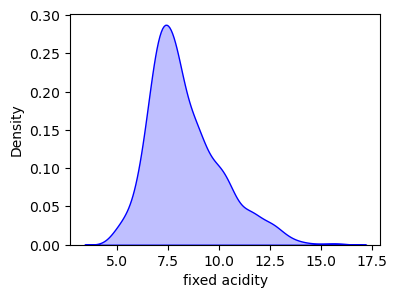

In [61]:
##### Data distribution of fixed acidity
plt.figure(figsize = (4,3))
sns.kdeplot(X_train["fixed acidity"] , color = "blue",fill = True)

In [62]:
from scipy import stats

((array([-3.22156323, -2.95817767, -2.81131498, ...,  2.81131498,
          2.95817767,  3.22156323], shape=(1087,)),
  array([ 4.7,  4.9,  5. , ..., 15. , 15.6, 15.9], shape=(1087,))),
 (np.float64(1.7051635245503676),
  np.float64(8.301747930082797),
  np.float64(0.9725479744875303)))

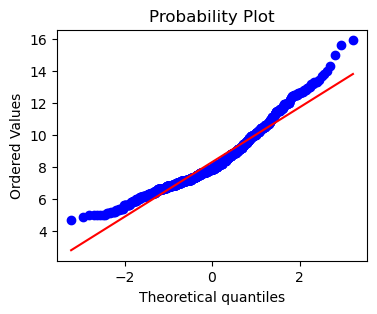

In [63]:
plt.figure(figsize=(4,3))
stats.probplot(X_train["fixed acidity"],dist="norm",plot=plt)

In [64]:
X_train[X_train["fixed acidity"]<=0]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol


# observation

- 1- the fixed acidity column is not a normal distribution

In [65]:
a=np.log1p(X_train["fixed acidity"])

<Axes: xlabel='fixed acidity', ylabel='Density'>

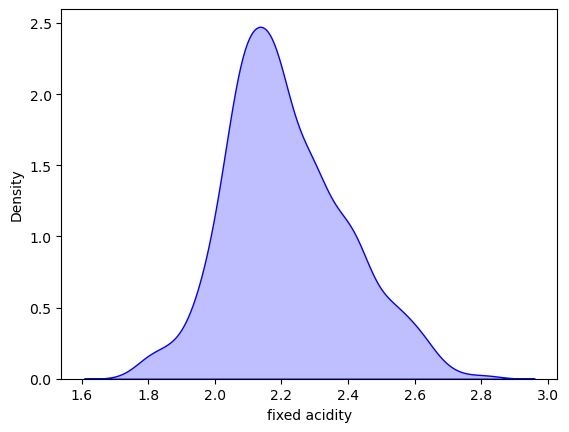

In [66]:
sns.kdeplot(a,color="blue",fill=True)

((array([-3.22156323, -2.95817767, -2.81131498, ...,  2.81131498,
          2.95817767,  3.22156323], shape=(1087,)),
  array([1.74046617, 1.77495235, 1.79175947, ..., 2.77258872, 2.8094027 ,
         2.82731362], shape=(1087,))),
 (np.float64(0.17883962072960322),
  np.float64(2.2136218474163094),
  np.float64(0.9917227224843382)))

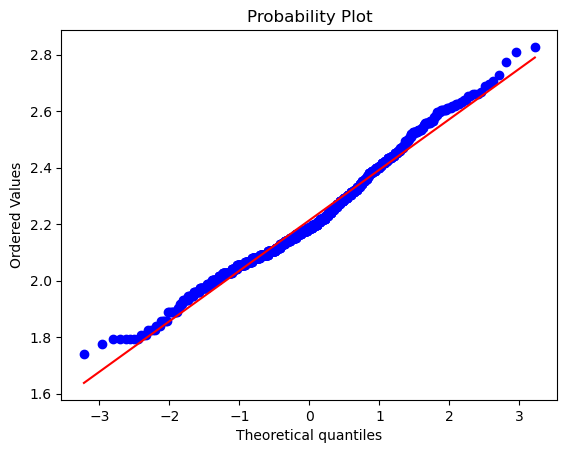

In [67]:
stats.probplot(a,dist="norm",plot=plt)

#### Power_Transform
1. Boxcox
2. yeojohnson

In [68]:
from sklearn.preprocessing import PowerTransformer

In [69]:
pt= PowerTransformer()
X_train_yeojohn=pt.fit_transform(X_train)
X_test_yj=pt.transform(X_test)

In [70]:
X_train_ydf=pd.DataFrame(X_train_yeojohn,columns=X_train.columns)
X_test_ydf=pd.DataFrame(X_test_yj,columns=X_test.columns)

In [71]:
X_train_ydf

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-1.056957,0.976302,-0.977542,0.567854,1.057255,0.089587,-0.442271,-0.027485,0.835414,-0.381477,-0.028742
1,-0.354774,-0.663818,-0.378351,-1.392767,0.008109,0.921108,0.646946,-0.107326,0.206494,-0.381477,-1.065002
2,0.609635,-0.867508,0.354483,-0.176370,-0.843693,-1.608930,-1.248137,-0.501541,-0.050554,1.063132,0.868969
3,0.042868,1.065224,-0.914321,0.786374,0.243367,0.470991,0.403482,1.432237,0.773382,0.644527,0.794105
4,0.450630,0.548696,0.256350,0.786374,0.416611,0.383244,0.312700,0.477646,-0.310837,-1.094815,-1.221671
...,...,...,...,...,...,...,...,...,...,...,...
1082,0.609635,-1.536112,0.989601,2.415968,1.281586,-1.939520,-1.917147,1.225686,-0.841394,-0.205942,0.635527
1083,-1.056957,1.087131,-0.266680,2.336424,-0.304429,1.224560,1.097214,0.530764,-0.115319,-0.768734,-1.385503
1084,-0.084275,-1.080357,0.816776,-0.371731,0.331578,-0.715096,-0.928021,-0.661516,0.270259,-0.205942,1.010499
1085,-0.498861,0.395290,0.256350,0.309463,-0.249897,0.193143,0.570085,0.052333,0.958915,-0.292298,-0.028742


<Axes: xlabel='fixed acidity', ylabel='Density'>

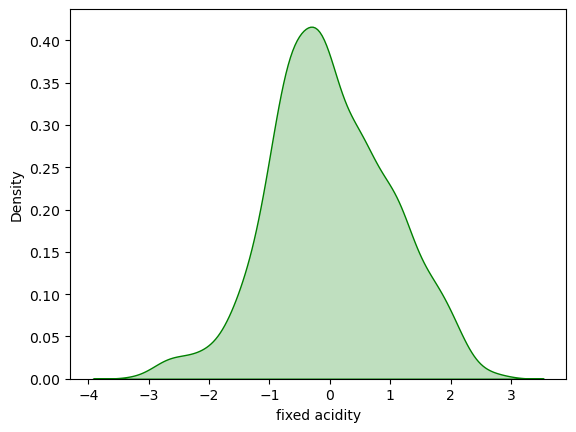

In [72]:
sns.kdeplot(X_train_ydf["fixed acidity"] , color = "green" , fill = True)

((array([-3.22156323, -2.95817767, -2.81131498, ...,  2.81131498,
          2.95817767,  3.22156323], shape=(1087,)),
  array([-3.1843573 , -2.90232017, -2.76770681, ...,  2.60886606,
          2.73883416,  2.80067401], shape=(1087,))),
 (np.float64(0.9992743915222319),
  np.float64(-1.568967387388007e-15),
  np.float64(0.9966934570433732)))

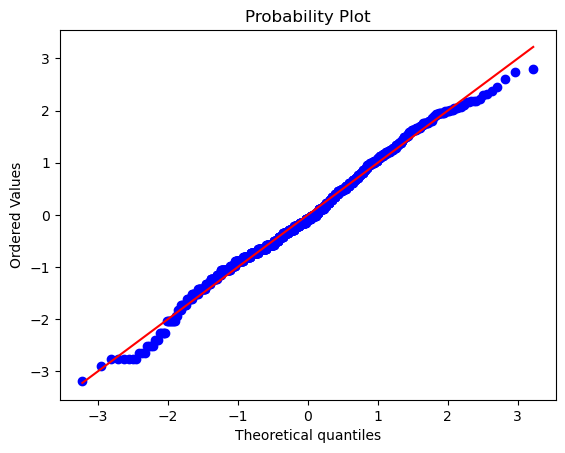

In [73]:
stats.probplot(X_train_ydf["fixed acidity"],dist = "norm" , plot = plt)

<Axes: xlabel='volatile acidity', ylabel='Density'>

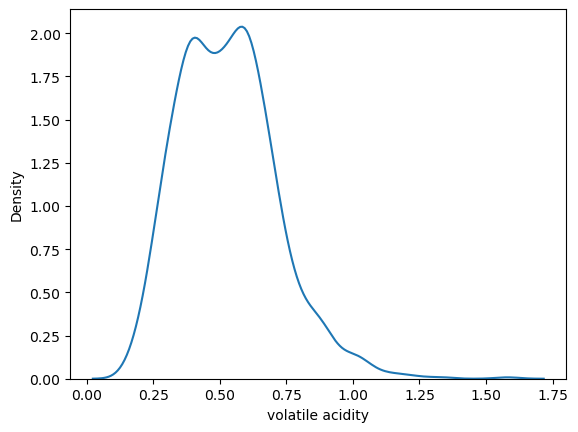

In [74]:
sns.kdeplot(X_train["volatile acidity"])

<Axes: xlabel='volatile acidity', ylabel='Density'>

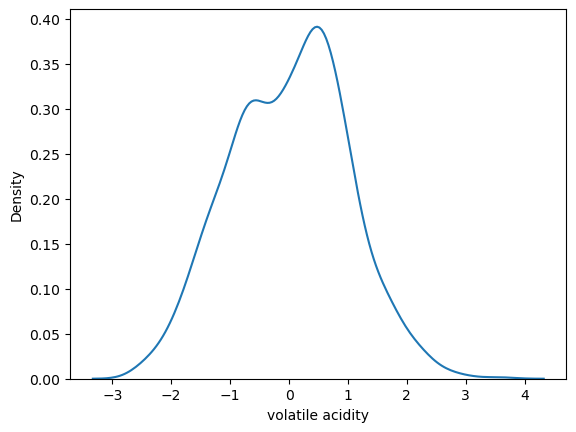

In [75]:
sns.kdeplot(X_train_ydf["volatile acidity"])

# Boxcox transformation

In [76]:
pt = PowerTransformer(method = "box-cox")
X_train_bc = pt.fit_transform(X_train)
X_test_bc = pt.transform(X_test)
# why error is coming here :
#Use Box-Cox only if all values are positive

ValueError: The Box-Cox transformation can only be applied to strictly positive data

#  quantile transformation

In [80]:
from sklearn.preprocessing import QuantileTransformer

In [85]:
qt=QuantileTransformer(output_distribution="normal")
X_train_qt=qt.fit_transform(X_train)
X_test_qt=qt.transform(X_test)

In [88]:
df1=pd.DataFrame(X_train_qt,columns=X_train.columns)
df2=pd.DataFrame(X_test_qt,columns=X_test.columns)

((array([-3.22156323, -2.95817767, -2.81131498, ...,  2.81131498,
          2.95817767,  3.22156323], shape=(1087,)),
  array([-5.19933758, -3.10257254, -2.65173198, ...,  2.90782547,
          3.13731475,  5.19933758], shape=(1087,))),
 (np.float64(1.0163370187608907),
  np.float64(0.0001490329154785801),
  np.float64(0.9963287270894611)))

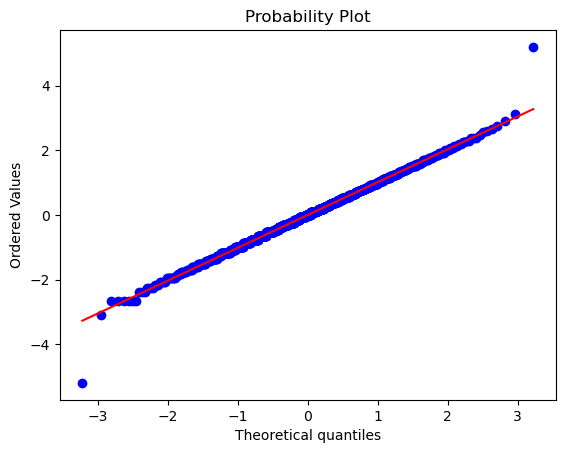

In [89]:
stats.probplot(df1["fixed acidity"],dist="norm",plot=plt)

<Axes: xlabel='fixed acidity', ylabel='Density'>

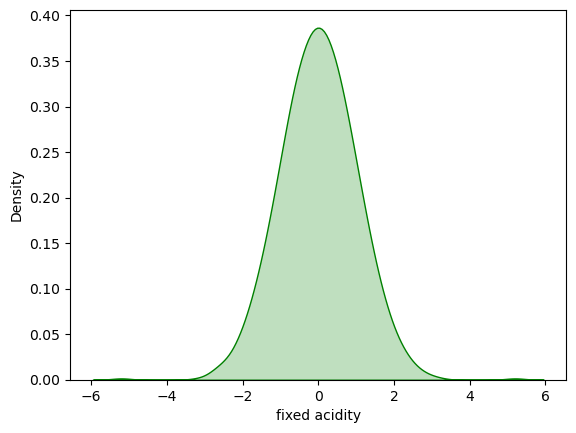

In [90]:
sns.kdeplot(df1["fixed acidity"],color="green",fill=True)

<Axes: xlabel='chlorides', ylabel='Density'>

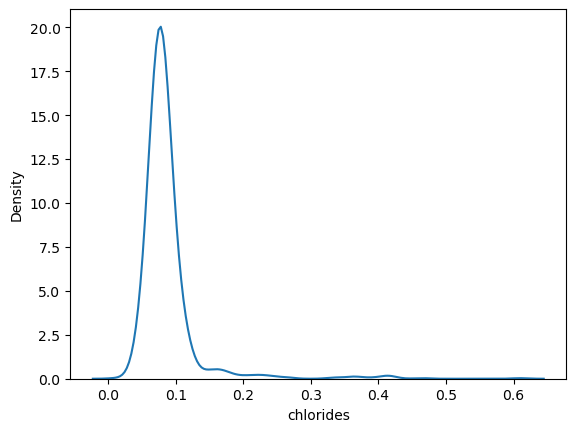

In [91]:
sns.kdeplot(X_train["chlorides"])

<Axes: xlabel='chlorides', ylabel='Density'>

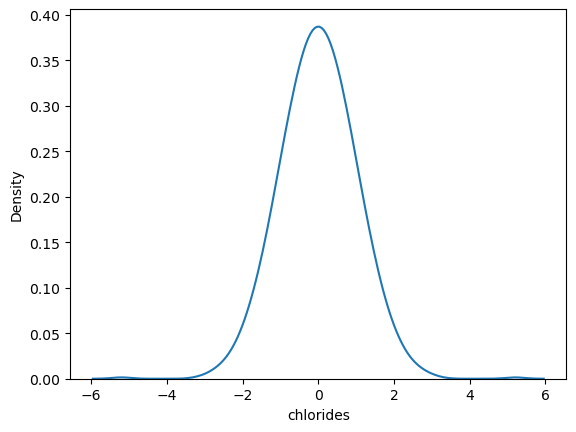

In [92]:
sns.kdeplot(df1["chlorides"])

In [93]:
df1["chlorides"].describe()

count    1.087000e+03
mean    -6.964179e-07
std      1.018078e+00
min     -5.199338e+00
25%     -6.689874e-01
50%      1.505539e-02
75%      6.737025e-01
max      5.199338e+00
Name: chlorides, dtype: float64

((array([-3.22156323, -2.95817767, -2.81131498, ...,  2.81131498,
          2.95817767,  3.22156323], shape=(1087,)),
  array([-5.19933758, -3.09459827, -2.88510261, ...,  2.88274169,
          3.09727701,  5.19933758], shape=(1087,))),
 (np.float64(1.0166171826236898),
  np.float64(-6.964178954883417e-07),
  np.float64(0.9964443037274271)))

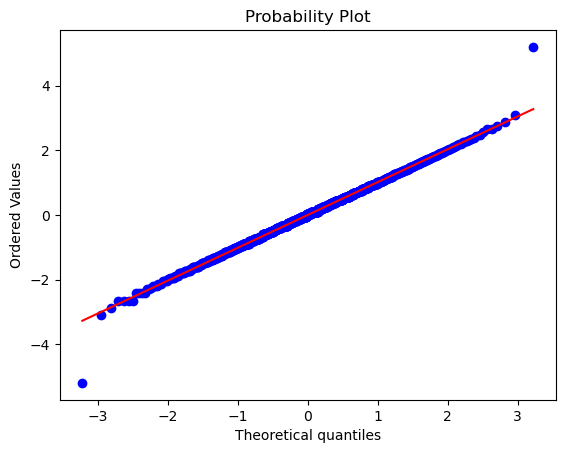

In [94]:
stats.probplot(df1["chlorides"],dist="norm",plot=plt)

In [96]:
plt.savefig("wine_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>